In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn.linear_model as lm
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import matplotlib.pyplot as plt


In [67]:
data_df = pd.read_csv("diabetes.csv")
X_data = data_df[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
y_data = data_df[["Outcome"]].values
data_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [68]:
#sns.boxplot(data=X_data, orient="h")

print("Maximum:", data_df["Insulin"].max())
print(data_df.loc[13])

max_insulin_row = data_df[data_df["Insulin"] > 700]
max_insulin_row

data_df_cleaned = data_df.copy()
data_df_cleaned.loc[data_df_cleaned["Insulin"] > 700] = data_df["Insulin"].mean()
#data_df_cleaned.loc[data_df_cleaned["Insulin"] > 700, "Insulin"] = data_df["Insulin"].mean()
print("Neues Maximum:", data_df_cleaned["Insulin"].max())
data_df_cleaned

Maximum: 846
Pregnancies                   1.000
Glucose                     189.000
BloodPressure                60.000
SkinThickness                23.000
Insulin                     846.000
BMI                          30.100
DiabetesPedigreeFunction      0.398
Age                          59.000
Outcome                       1.000
Name: 13, dtype: float64
Neues Maximum: 680.0


C:\Users\Anton\AppData\Local\Temp\ipykernel_23320\1114855045.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.79947916666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df_cleaned.loc[data_df_cleaned["Insulin"] > 700] = data_df["Insulin"].mean()
C:\Users\Anton\AppData\Local\Temp\ipykernel_23320\1114855045.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.79947916666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df_cleaned.loc[data_df_cleaned["Insulin"] > 700] = data_df["Insulin"].mean()
C:\Users\Anton\AppData\Local\Temp\ipykernel_23320\1114855045.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.79947916666667' has dtype 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
764,2.0,122.0,70.0,27.0,0.0,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,0.0,0.0,30.1,0.349,47.0,1.0


#### Aufgabe 1

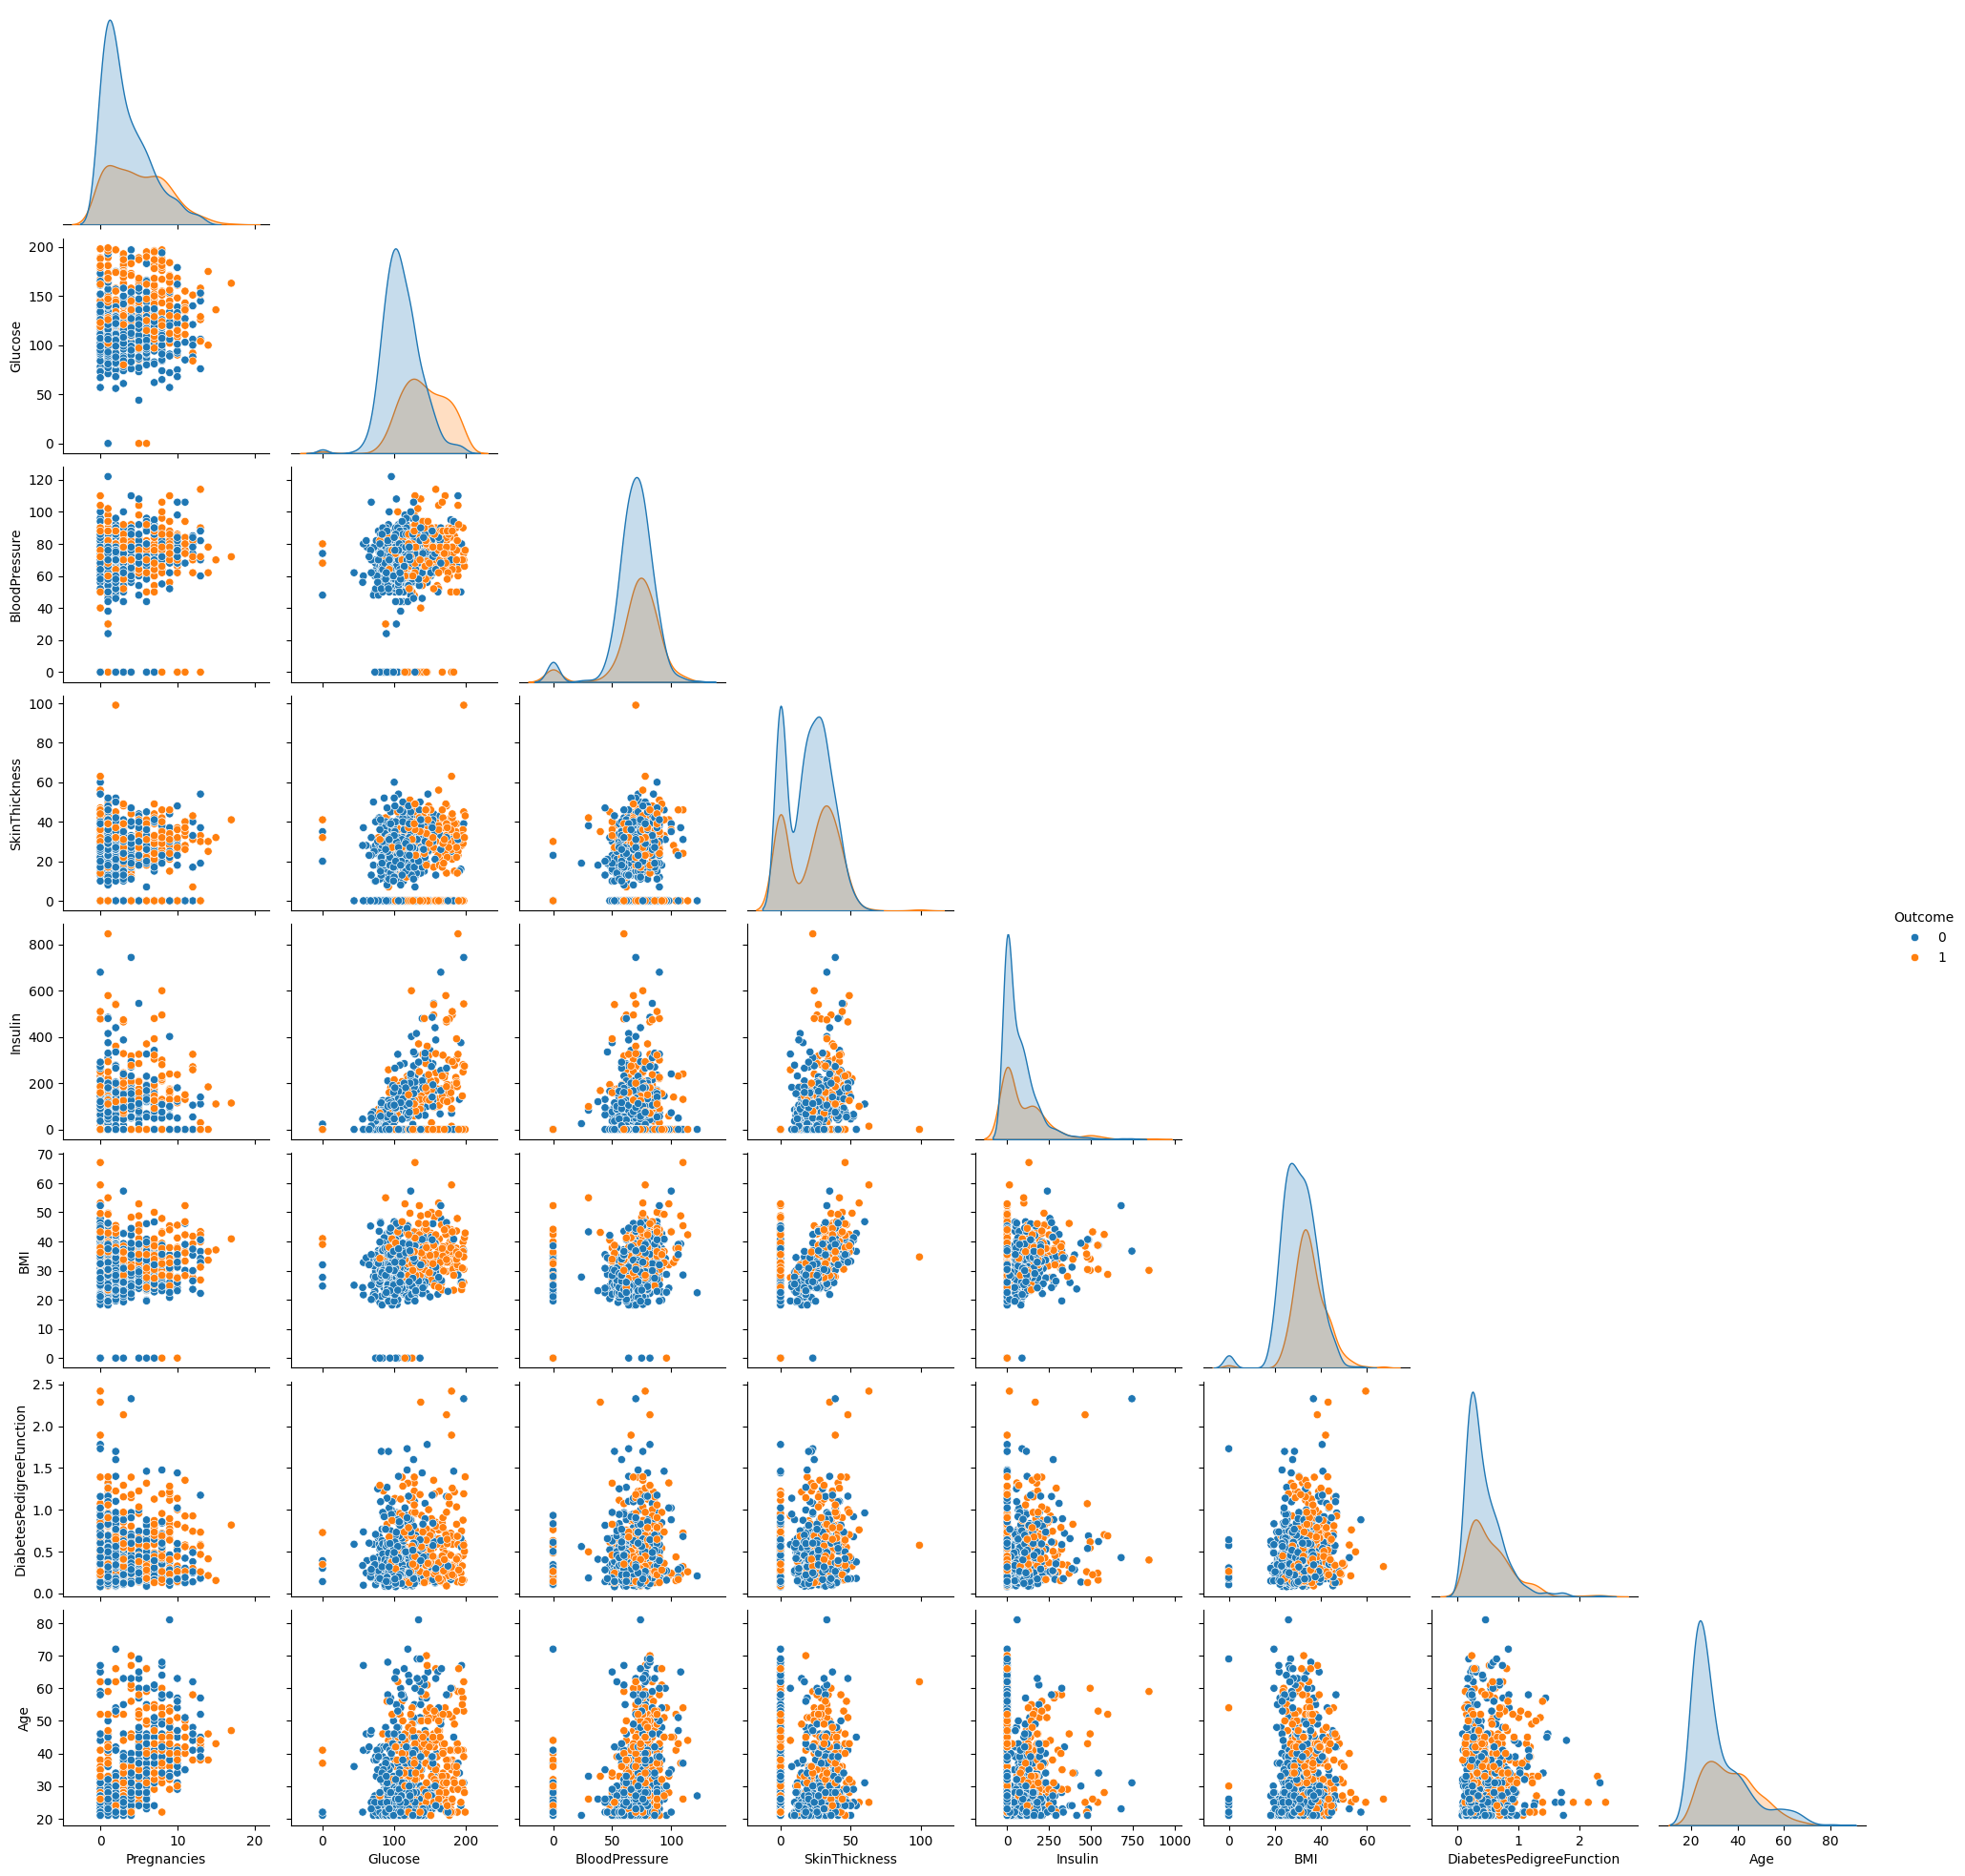

In [55]:
data_df = pd.read_csv("diabetes.csv")

# a) Überprüfen Sie die Datenstruktur der einzelnen Einträge.
data_df.dtypes

# b) Überprüfen Sie die Anzahl der Merkmalseinträge und listen Sie die fehlenden Werte pro Merkmal auf.
data_df.count()
data_df.isnull().sum()

# c) Berechnen Sie wichtigsten statistischen Werte für jedes Merkmal.
data_df.describe()

# d) Geben Sie die folgenden Plots aus:

#   – Ein Histogramm für jedes Merkmal.
#data_df.hist(figsize=(20, 20))

#   – Scatter-Plots für paarweise verschiedene Merkmale.
list = []
for pair_i in X_data:
    for pair_j in X_data:
        if pair_j in list:
            continue
        if pair_i == pair_j:
            continue
        name_x = pair_i
        name_y = pair_j
        #sns.jointplot(x= data_df[pair_i], y = data_df[pair_j])
        list.append(pair_i)

sns.pairplot(data_df, hue="Outcome", corner=True)

#   – Die Korrelationsmatrix der Merkmale.
X_data.corr()

# e) Trennen Sie aus dem gesamten Datensatz ein Drittel der Datenmenge ab und bilden Sie daraus einen Testdatensatz. Skalieren Sie die für die folgenden Aufgaben benötigten Datenmengen.
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=1/3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Aufgabe 2

In [4]:
#  a) Für welche Anzahl an Iterationen finden Sie eine optimale Näherung? Begründen Sie Ihre Auswahl.

iter_list = [50, 100, 200, 500, 1000]

for iter in iter_list:
    logr = lm.LogisticRegression(max_iter = iter)
    logr.fit(X_train,y_train)
    score = logr.score(X_train,y_train)
    print(iter, score)

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Anton\Documents\HfT\S5\02 - Data Scienc

50 0.669921875
100 0.78125
200 0.779296875
500 0.779296875
1000 0.779296875


c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
# b) Schreiben Sie eine Funktion, welche für zwei ausgewählte Merkmale den zugehörigen Scatterplot ausgibt.
def scatterplotOutput(merkmal_1, merkmal_2, X, y):
    plt.figure(figsize=(8, 6))
    sns.jointplot(x=X[merkmal_1], y=X[merkmal_2], hue=y.ravel())
    plt.show()

####  Aufgabe 3 

In [6]:
# a) Vergleichen Sie einen linearen, einen polynomialen und einen Gauß-Kernel. Bestimmen Sie für jeden
#  Kernel eine optimale Parameter-Einstellung. Begründen Sie Ihre Auswahl.

X_linear = X_train_scaled.copy()
y_linear = y_train.copy()

model_linear = SVC(kernel='linear', C=1, gamma=1)
model_linear.fit(X_linear, y_linear)
print("Linearen-Kernel: ",model_linear.score(X_linear, y_linear))

Linearen-Kernel:  0.779296875


c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [7]:
X_poly = X_train_scaled.copy()
y_poly = y_train.copy()

model_poly = SVC(kernel='poly', C=1, gamma=1) 
model_poly.fit(X_poly, y_poly)
print("Polynomialen-Kernel: ", model_poly.score(X_poly, y_poly))

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Polynomialen-Kernel:  0.873046875


In [8]:
X_gaus = X_train_scaled.copy()
y_gaus = y_train.copy()

model_gauss = SVC(kernel='rbf', C=1, gamma=1) 
model_gauss.fit(X_gaus, y_gaus)
print("Gauß-Kernel: ", model_gauss.score(X_gaus, y_gaus))

Gauß-Kernel:  0.96484375


c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
#  b) Nutzen Sie die Funktion aus Aufgabenteil 2b), um für jeden Kernel analoge Plots darstellen zu können.
# offen